# Engagement Survey Analysis

## Purpose
Analyze pulse survey results to identify engagement drivers, calculate eNPS, and segment the workforce by engagement level.

## Key Metrics
- **eNPS (Employee Net Promoter Score)**: % Promoters (9-10) - % Detractors (0-6)
- **Engagement Index**: Composite score from Gallup Q12 items
- **Engagement Segmentation**: Actively Disengaged → Highly Engaged

## Research Foundation
- Gallup Q12 engagement framework (Harter et al., 2002)
- eNPS as predictor of organizational performance (Reichheld, 2003)

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsimport os# Set display optionspd.set_option('display.max_columns', None)pd.set_option('display.width', None)sns.set_style('whitegrid')plt.rcParams['figure.figsize'] = (12, 6)# Generate data if it doesn't existif not os.path.exists('../data/pulse_surveys.csv'):    print("Generating sample data...")    exec(open('../data/generate_sample_data.py').read())else:    print("Loading existing data...")# Load datasetspulse_surveys = pd.read_csv('../data/pulse_surveys.csv')employees = pd.read_csv('../data/employees.csv')print(f"\nLoaded {len(pulse_surveys)} survey responses from {pulse_surveys['survey_id'].nunique()} quarters")print(f"Loaded {len(employees)} employee records")

Generating sample data...
Generating employee data...
Generating pulse survey data...
Generating intervention programs data...
Generating engagement trends...

Saving datasets...

DATA GENERATION COMPLETE
Generated 500 employee records
Generated 1694 pulse survey responses
Generated 1 intervention programs
Generated 4 quarterly trend records

Datasets saved to ../data/

📊 ENGAGEMENT SUMMARY
Average Engagement Index: 4.05/5.0
Average Wellbeing Index: 3.43/5.0
Average eNPS: 7.7/10

⚠️ BURNOUT RISK
High burnout risk (>70): 15 employees (3.0%)
Moderate burnout risk (50-70): 100 employees
Low burnout risk (<50): 385 employees

💼 WORK HOURS
Average weekly hours: 45.1
Working >50 hours/week: 93 employees (18.6%)
Average PTO usage: 60.6%

🚪 ATTRITION
Overall attrition rate: 7.2%
Attrition among highly disengaged (<30%): 66.7%
Attrition among highly engaged (>70%): 6.5%

✅ All datasets ready for analysis!


Loaded 1694 survey responses from 4 quarters
Loaded 500 employee records


## 1. eNPS Analysis

Employee Net Promoter Score measures likelihood to recommend the company as a place to work.

eNPS ANALYSIS - Q4 2024

Overall eNPS: 15.8
  Promoters (9-10): 40.1%
  Passives (7-8):   35.6%
  Detractors (0-6): 24.3%

📊 BENCHMARK COMPARISON:
  FAIR - Below average, action needed
  (Industry benchmark for tech: 20-40)


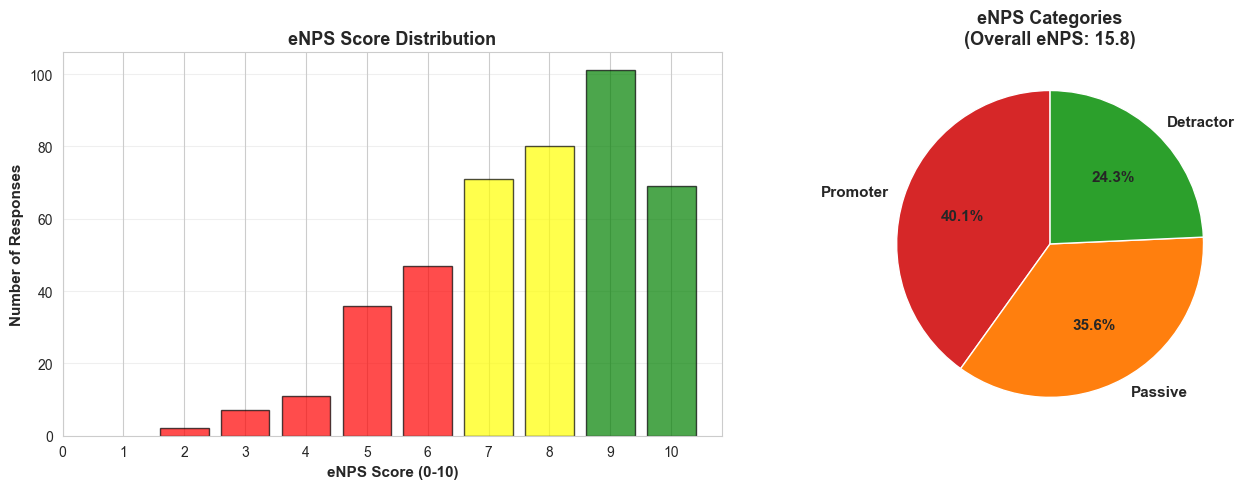

In [2]:
# Use most recent surveylatest_survey = pulse_surveys[pulse_surveys['survey_id'] == 'Q4_2025'].copy()# Categorize eNPS responseslatest_survey['enps_category'] = pd.cut(    latest_survey['enps_score'],    bins=[-1, 6, 8, 10],    labels=['Detractor', 'Passive', 'Promoter'])# Calculate eNPSpromoters_pct = (latest_survey['enps_score'] >= 9).sum() / len(latest_survey) * 100detractors_pct = (latest_survey['enps_score'] <= 6).sum() / len(latest_survey) * 100passives_pct = ((latest_survey['enps_score'] >= 7) & (latest_survey['enps_score'] <= 8)).sum() / len(latest_survey) * 100enps = promoters_pct - detractors_pctprint(f"{'='*80}")print(f"eNPS ANALYSIS - Q4 2024")print(f"{'='*80}")print(f"\nOverall eNPS: {enps:.1f}")print(f"  Promoters (9-10): {promoters_pct:.1f}%")print(f"  Passives (7-8):   {passives_pct:.1f}%")print(f"  Detractors (0-6): {detractors_pct:.1f}%")# Benchmark interpretationprint(f"\n📊 BENCHMARK COMPARISON:")if enps >= 50:    interpretation = "EXCELLENT - World-class employee sentiment"elif enps >= 30:    interpretation = "GOOD - Above average, room for improvement"elif enps >= 10:    interpretation = "FAIR - Below average, action needed"else:    interpretation = "⚠ POOR - Urgent intervention required"    print(f"  {interpretation}")print(f"  (Industry benchmark for tech: 20-40)")# Visualize eNPS distributionfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))# Distribution of scoresscore_counts = latest_survey['enps_score'].value_counts().sort_index()colors = ['red' if s <= 6 else 'yellow' if s <= 8 else 'green' for s in score_counts.index]ax1.bar(score_counts.index, score_counts.values, color=colors, alpha=0.7, edgecolor='black')ax1.set_xlabel('eNPS Score (0-10)', fontsize=11, fontweight='bold')ax1.set_ylabel('Number of Responses', fontsize=11, fontweight='bold')ax1.set_title('eNPS Score Distribution', fontsize=13, fontweight='bold')ax1.set_xticks(range(0, 11))ax1.grid(axis='y', alpha=0.3)# Category breakdowncategory_counts = latest_survey['enps_category'].value_counts()colors_cat = ['#d62728', '#ff7f0e', '#2ca02c']  # Red, Orange, Greenax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',        colors=colors_cat, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})ax2.set_title(f'eNPS Categories\n(Overall eNPS: {enps:.1f})', fontsize=13, fontweight='bold')plt.tight_layout()plt.show()print(f"\n{'='*80}")

## 2. Engagement Index by Department

Identify which departments have highest and lowest engagement.

ENGAGEMENT BY DEPARTMENT
                  Engagement Index  Std Dev  Response Count  Avg eNPS  \
department                                                              
Product                       4.35     0.37              63      8.65   
Engineering                   4.28     0.48              48      8.27   
Finance                       4.23     0.49              52      8.27   
HR                            4.16     0.51              57      7.98   
Marketing                     4.09     0.53              58      7.95   
Customer Success              3.86     0.61              58      6.88   
Operations                    3.73     0.68              49      6.94   
Sales                         3.52     0.65              39      6.15   

                  Likelihood to Leave  
department                             
Product                          1.59  
Engineering                      1.70  
Finance                          1.79  
HR                               1.85  
Mark

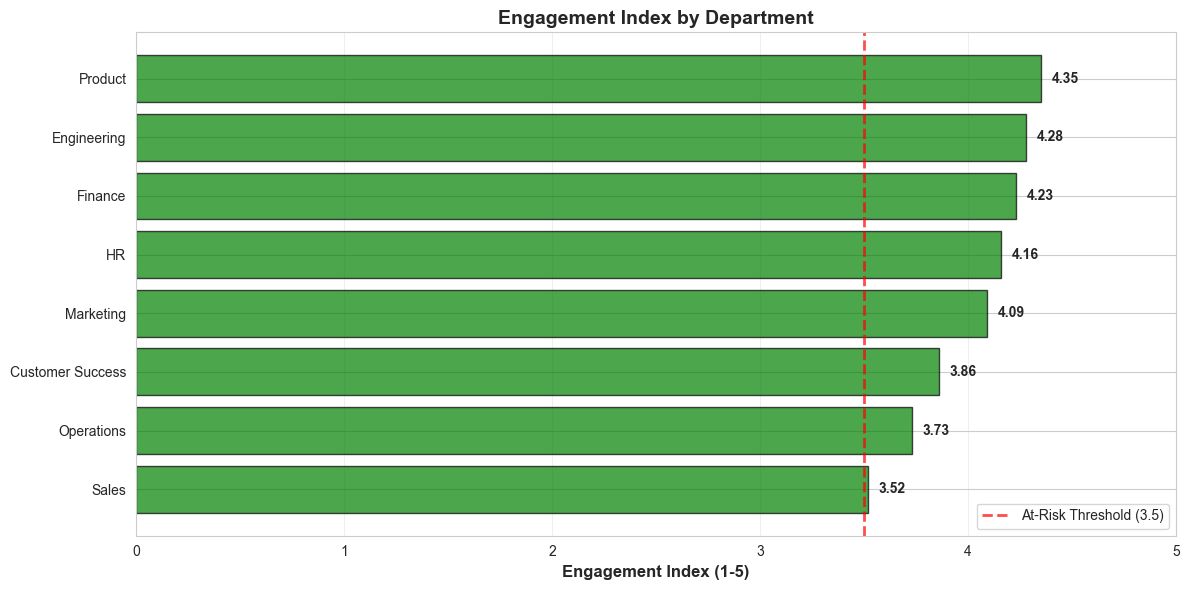

In [3]:
# Calculate department-level engagementdept_engagement = latest_survey.groupby('department').agg({    'engagement_index': ['mean', 'std', 'count'],    'enps_score': 'mean',    'likelihood_to_leave': 'mean'}).round(2)dept_engagement.columns = ['Engagement Index', 'Std Dev', 'Response Count', 'Avg eNPS', 'Likelihood to Leave']dept_engagement = dept_engagement.sort_values('Engagement Index', ascending=False)print(f"{'='*80}")print(f"ENGAGEMENT BY DEPARTMENT")print(f"{'='*80}")print(dept_engagement)# Identify at-risk departmentsat_risk_threshold = 3.0at_risk_depts = dept_engagement[dept_engagement['Engagement Index'] < at_risk_threshold]if len(at_risk_depts) > 0:    print(f"\n⚠ AT-RISK DEPARTMENTS (Engagement < {at_risk_threshold}):")    for dept in at_risk_depts.index:        eng = at_risk_depts.loc[dept, 'Engagement Index']        leave = at_risk_depts.loc[dept, 'Likelihood to Leave']        print(f"  • {dept}: Engagement={eng:.2f}, Likely to Leave={leave:.2f}/5")        print(f"\n{'='*80}")# Visualize department comparisonfig, ax = plt.subplots(figsize=(12, 6))dept_sorted = dept_engagement.sort_values('Engagement Index')colors = ['red' if x < 3.0 else 'orange' if x < 3.5 else 'green' for x in dept_sorted['Engagement Index']]bars = ax.barh(dept_sorted.index, dept_sorted['Engagement Index'], color=colors, alpha=0.7, edgecolor='black')# Add threshold lineax.axvline(x=3.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='At-Risk Threshold (3.5)')# Add value labelsfor i, (idx, row) in enumerate(dept_sorted.iterrows()):    ax.text(row['Engagement Index'] + 0.05, i, f"{row['Engagement Index']:.2f}",             va='center', fontsize=10, fontweight='bold')ax.set_xlabel('Engagement Index (1-5)', fontsize=12, fontweight='bold')ax.set_title('Engagement Index by Department', fontsize=14, fontweight='bold')ax.set_xlim(0, 5)ax.legend()ax.grid(axis='x', alpha=0.3)plt.tight_layout()plt.show()

## 3. Engagement Driver Analysis

Which factors most strongly predict overall engagement? Based on Gallup Q12 framework.

**Understanding Correlation (r=):**
- The correlation coefficient (r) measures how strongly two variables are related
- **r = 0.7-1.0**: Very strong relationship - highly impactful driver
- **r = 0.5-0.7**: Strong relationship - significant driver
- **r = 0.3-0.5**: Moderate relationship - meaningful driver
- **r = 0.0-0.3**: Weak relationship - minor driver

**Statistical Significance:**
- **✓✓** = Highly significant (p < 0.01) - very confident this relationship is real, not random
- **✓** = Significant (p < 0.05) - confident this relationship is real, not random
- Higher r= values indicate stronger drivers of engagement - focus interventions here for maximum impact

In [ ]:
# Engagement dimensions from Gallup Q12engagement_dimensions = [    'expectations_clarity',    'materials_equipment',    'opportunity_best',    'recognition_praise',    'cares_about_me',    'development_encouraged',    'opinions_count',    'mission_purpose',    'quality_commitment',    'best_friend_work',    'progress_discussion',    'learn_grow']# Calculate correlation between each dimension and overall engagement indexcorrelations = {}for dim in engagement_dimensions:    corr, pval = stats.pearsonr(latest_survey[dim], latest_survey['engagement_index'])    correlations[dim] = {'correlation': corr, 'p_value': pval}corr_df = pd.DataFrame(correlations).Tcorr_df = corr_df.sort_values('correlation', ascending=False)corr_df['significant'] = corr_df['p_value'] < 0.05corr_df['highly_significant'] = corr_df['p_value'] < 0.01# Display readable namesreadable_names = {    'expectations_clarity': 'Clear Expectations',    'materials_equipment': 'Materials & Equipment',    'opportunity_best': 'Opportunity to Do Best',    'recognition_praise': 'Recognition & Praise',    'cares_about_me': 'Someone Cares About Me',    'development_encouraged': 'Development Encouraged',    'opinions_count': 'My Opinions Count',    'mission_purpose': 'Mission/Purpose',    'quality_commitment': 'Quality Commitment',    'best_friend_work': 'Best Friend at Work',    'progress_discussion': 'Progress Discussions',    'learn_grow': 'Learn & Grow'}corr_df['readable_name'] = corr_df.index.map(readable_names)print(f"{'='*80}")print(f"ENGAGEMENT DRIVERS - Correlation with Overall Engagement")print(f"{'='*80}")print(f"\nLegend:")print(f"  r=     Correlation coefficient (0.0-1.0, higher = stronger driver)")print(f"  ✓✓     Highly significant (p<0.01) - very confident relationship is real")print(f"  ✓      Significant (p<0.05) - confident relationship is real")print(f"\nTop 5 Drivers:")for i, (idx, row) in enumerate(corr_df.head(5).iterrows(), 1):    if row['highly_significant']:        sig_marker = "✓✓"    elif row['significant']:        sig_marker = "✓"    else:        sig_marker = ""    print(f"  {i}. {row['readable_name']:30s}: r={row['correlation']:.3f} {sig_marker}")print(f"\nBottom 3 Drivers (Lowest Correlation):")for i, (idx, row) in enumerate(corr_df.tail(3).iterrows(), 1):    if row['highly_significant']:        sig_marker = "✓✓"    elif row['significant']:        sig_marker = "✓"    else:        sig_marker = ""    print(f"  {i}. {row['readable_name']:30s}: r={row['correlation']:.3f} {sig_marker}")print(f"\n{'='*80}")# Visualize driver correlationsfig, ax = plt.subplots(figsize=(12, 8))y_pos = np.arange(len(corr_df))colors = ['green' if corr >= 0.5 else 'orange' if corr >= 0.3 else 'red'           for corr in corr_df['correlation']]bars = ax.barh(y_pos, corr_df['correlation'], color=colors, alpha=0.7, edgecolor='black')ax.set_yticks(y_pos)ax.set_yticklabels(corr_df['readable_name'], fontsize=10)ax.set_xlabel('Correlation with Overall Engagement (r)', fontsize=12, fontweight='bold')ax.set_title('Engagement Drivers - Correlation Analysis\n(Green=Strong r≥0.5, Orange=Moderate r≥0.3, Red=Weak)', fontsize=14, fontweight='bold')ax.set_xlim(0, 1.0)# Add value labelsfor i, (idx, row) in enumerate(corr_df.iterrows()):    ax.text(row['correlation'] + 0.02, i, f"{row['correlation']:.2f}",             va='center', fontsize=9, fontweight='bold')ax.grid(axis='x', alpha=0.3)plt.tight_layout()plt.show()# Strategic insightprint(f"\n💡 STRATEGIC INSIGHT:")print(f"{'='*80}")top_driver = corr_df.iloc[0]print(f"The strongest driver of engagement is '{top_driver['readable_name']}'")print(f"(r={top_driver['correlation']:.3f}).")print(f"\nFocus improvement efforts on the top 3-5 drivers to maximize impact.")print(f"Factors with r>0.5 are strong drivers - prioritize these for engagement initiatives.")print(f"{'='*80}")

## 4. Manager Impact on Team Engagement

Analyze how manager effectiveness correlates with team engagement scores.

In [ ]:
# Merge manager effectiveness scoressurvey_with_mgr = latest_survey.copy()# Categorize manager effectivenesssurvey_with_mgr['manager_category'] = pd.cut(    survey_with_mgr['manager_effectiveness_score'],    bins=[0, 0.5, 0.7, 0.85, 1.0],    labels=['Ineffective', 'Adequate', 'Strong', 'Exceptional'])# Engagement by manager qualitymgr_engagement = survey_with_mgr.groupby('manager_category').agg({    'engagement_index': ['mean', 'std', 'count'],    'enps_score': 'mean',    'likelihood_to_leave': 'mean'}).round(2)mgr_engagement.columns = ['Engagement Index', 'Std Dev', 'Count', 'Avg eNPS', 'Likelihood to Leave']print(f"{'='*80}")print(f"MANAGER EFFECTIVENESS IMPACT ON TEAM ENGAGEMENT")print(f"{'='*80}")print(mgr_engagement)# Calculate correlationcorr_mgr, pval_mgr = stats.pearsonr(survey_with_mgr['manager_effectiveness_score'],                                       survey_with_mgr['engagement_index'])print(f"\nCorrelation between manager effectiveness and team engagement: r={corr_mgr:.3f}")print(f"  (r={corr_mgr:.3f} means {'very strong' if corr_mgr >= 0.7 else 'strong' if corr_mgr >= 0.5 else 'moderate'} positive relationship)")if pval_mgr < 0.01:    print(f"  ✓✓ HIGHLY SIGNIFICANT (p<0.01): Very confident manager quality predicts team engagement")elif pval_mgr < 0.05:    print(f"  ✓ SIGNIFICANT (p<0.05): Confident manager quality predicts team engagement")# Engagement gap between best and worst managersexceptional_eng = mgr_engagement.loc['Exceptional', 'Engagement Index']ineffective_eng = mgr_engagement.loc['Ineffective', 'Engagement Index']engagement_gap = exceptional_eng - ineffective_engprint(f"\n📊 ENGAGEMENT GAP:")print(f"  Exceptional managers: {exceptional_eng:.2f}/5.0")print(f"  Ineffective managers: {ineffective_eng:.2f}/5.0")print(f"  Gap: {engagement_gap:.2f} points ({engagement_gap/5*100:.1f}% difference)")print(f"\n{'='*80}")# Visualize manager impactfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))# Engagement by manager categorymgr_categories = ['Ineffective', 'Adequate', 'Strong', 'Exceptional']engagement_values = [mgr_engagement.loc[cat, 'Engagement Index'] if cat in mgr_engagement.index else 0                      for cat in mgr_categories]colors_mgr = ['red', 'orange', 'lightgreen', 'green']bars = ax1.bar(mgr_categories, engagement_values, color=colors_mgr, alpha=0.7, edgecolor='black')ax1.set_ylabel('Engagement Index', fontsize=11, fontweight='bold')ax1.set_title('Team Engagement by Manager Effectiveness', fontsize=13, fontweight='bold')ax1.set_ylim(0, 5)ax1.grid(axis='y', alpha=0.3)# Add value labelsfor bar, val in zip(bars, engagement_values):    height = bar.get_height()    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')# Scatter plot: Manager score vs engagementax2.scatter(survey_with_mgr['manager_effectiveness_score'],            survey_with_mgr['engagement_index'],            alpha=0.4, s=50, edgecolors='black', linewidth=0.5)# Add trend linez = np.polyfit(survey_with_mgr['manager_effectiveness_score'],                survey_with_mgr['engagement_index'], 1)p = np.poly1d(z)x_trend = np.linspace(0, 1, 100)ax2.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'r={corr_mgr:.3f}')ax2.set_xlabel('Manager Effectiveness Score', fontsize=11, fontweight='bold')ax2.set_ylabel('Engagement Index', fontsize=11, fontweight='bold')ax2.set_title('Manager Effectiveness vs Team Engagement', fontsize=13, fontweight='bold')ax2.legend()ax2.grid(alpha=0.3)plt.tight_layout()plt.show()print(f"\n💡 STRATEGIC INSIGHT:")print(f"{'='*80}")print(f"Manager quality explains significant variance in team engagement.")print(f"Teams with exceptional managers score {engagement_gap:.1f} points higher than")print(f"teams with ineffective managers.")print(f"\n→ Investing in manager development is a high-leverage engagement strategy.")print(f"{'='*80}")

## 5. Engagement Segmentation

Categorize employees by engagement level to target interventions.

ENGAGEMENT SEGMENTATION
  Highly Engaged           : 247 employees ( 58.3%)
  Engaged                  : 100 employees ( 23.6%)
  Not Engaged              :  70 employees ( 16.5%)
  Actively Disengaged      :   7 employees (  1.7%)


SEGMENT PROFILES:
                     enps_score  likelihood_to_leave  overall_satisfaction
engagement_segment                                                        
Actively Disengaged        3.43                 3.63                  2.23
Not Engaged                5.26                 2.77                  3.13
Engaged                    7.22                 2.18                  3.85
Highly Engaged             8.72                 1.53                  4.45


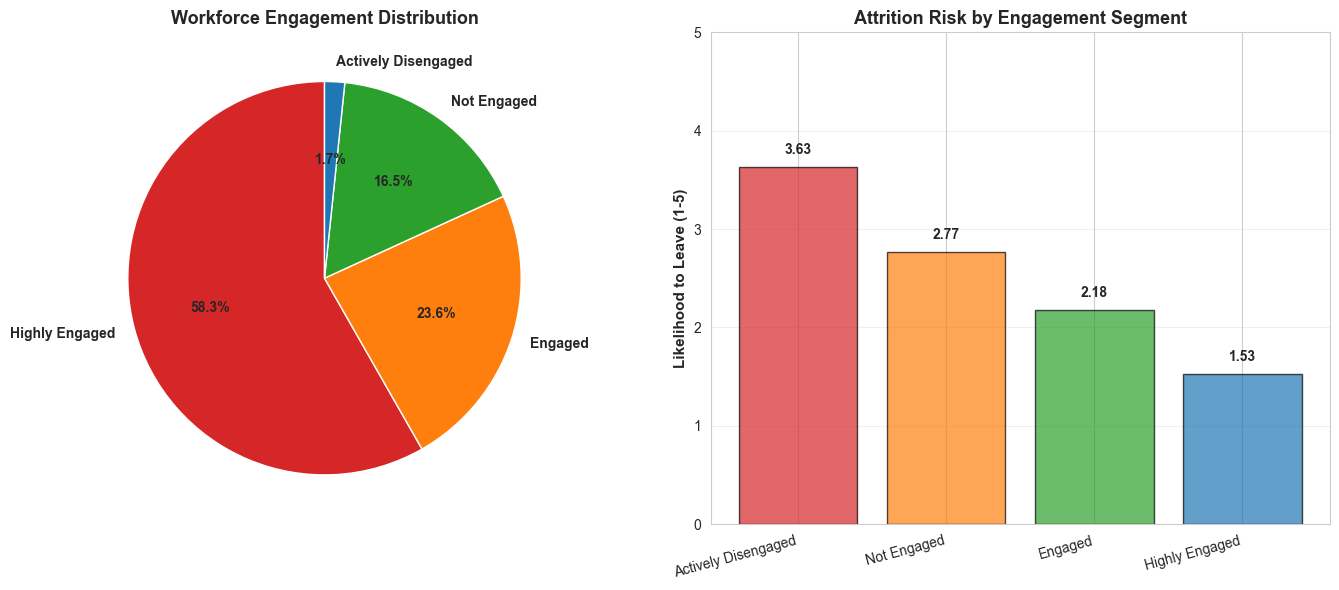


💡 STRATEGIC RECOMMENDATIONS:

1. ACTIVELY DISENGAGED (1.7%):
   • HIGH PRIORITY: Immediate manager interventions
   • Conduct stay interviews to understand root causes
   • Consider role changes or team transfers if needed

2. NOT ENGAGED (16.5%):
   • Focus on top engagement drivers identified in analysis
   • Increase manager 1:1 frequency and quality
   • Provide clearer career development paths

3. HIGHLY ENGAGED (58.3%):
   • Retain through growth opportunities and recognition
   • Use as mentors/culture champions
   • Ensure competitive compensation to prevent poaching



In [6]:
# Create engagement segmentslatest_survey['engagement_segment'] = pd.cut(    latest_survey['engagement_index'],    bins=[0, 2.5, 3.5, 4.0, 5.0],    labels=['Actively Disengaged', 'Not Engaged', 'Engaged', 'Highly Engaged'])# Calculate segment sizessegment_counts = latest_survey['engagement_segment'].value_counts()segment_pcts = (segment_counts / len(latest_survey) * 100).round(1)print(f"{'='*80}")print(f"ENGAGEMENT SEGMENTATION")print(f"{'='*80}")for segment in ['Highly Engaged', 'Engaged', 'Not Engaged', 'Actively Disengaged']:    if segment in segment_counts.index:        count = segment_counts[segment]        pct = segment_pcts[segment]        print(f"  {segment:25s}: {count:3d} employees ({pct:5.1f}%)")print(f"\n{'='*80}")# Analyze segment characteristicssegment_profile = latest_survey.groupby('engagement_segment').agg({    'enps_score': 'mean',    'likelihood_to_leave': 'mean',    'overall_satisfaction': 'mean'}).round(2)print(f"\nSEGMENT PROFILES:")print(segment_profile)# Visualize segmentationfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))# Pie chart of segmentscolors_seg = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']  # Red, Orange, Green, Blueax1.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',        colors=colors_seg[:len(segment_counts)], startangle=90,         textprops={'fontsize': 10, 'fontweight': 'bold'})ax1.set_title('Workforce Engagement Distribution', fontsize=13, fontweight='bold')# Bar chart of attrition risk by segmentsegments_order = ['Actively Disengaged', 'Not Engaged', 'Engaged', 'Highly Engaged']leave_risk = [segment_profile.loc[seg, 'likelihood_to_leave']               if seg in segment_profile.index else 0               for seg in segments_order]bars = ax2.bar(range(len(segments_order)), leave_risk,                color=colors_seg[:len(segments_order)], alpha=0.7, edgecolor='black')ax2.set_xticks(range(len(segments_order)))ax2.set_xticklabels(segments_order, rotation=15, ha='right')ax2.set_ylabel('Likelihood to Leave (1-5)', fontsize=11, fontweight='bold')ax2.set_title('Attrition Risk by Engagement Segment', fontsize=13, fontweight='bold')ax2.set_ylim(0, 5)ax2.grid(axis='y', alpha=0.3)# Add value labelsfor bar, val in zip(bars, leave_risk):    height = bar.get_height()    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')plt.tight_layout()plt.show()# Strategic recommendationsactively_disengaged_pct = segment_pcts.get('Actively Disengaged', 0)highly_engaged_pct = segment_pcts.get('Highly Engaged', 0)print(f"\n💡 STRATEGIC RECOMMENDATIONS:")print(f"{'='*80}")print(f"\n1. ACTIVELY DISENGAGED ({actively_disengaged_pct:.1f}%):")print(f"   • HIGH PRIORITY: Immediate manager interventions")print(f"   • Conduct stay interviews to understand root causes")print(f"   • Consider role changes or team transfers if needed")print(f"\n2. NOT ENGAGED ({segment_pcts.get('Not Engaged', 0):.1f}%):")print(f"   • Focus on top engagement drivers identified in analysis")print(f"   • Increase manager 1:1 frequency and quality")print(f"   • Provide clearer career development paths")print(f"\n3. HIGHLY ENGAGED ({highly_engaged_pct:.1f}%):")print(f"   • Retain through growth opportunities and recognition")print(f"   • Use as mentors/culture champions")print(f"   • Ensure competitive compensation to prevent poaching")print(f"\n{'='*80}")

## Key Takeaways

1. **eNPS provides quick pulse**: Use eNPS as a simple, trackable metric for overall employee sentiment
2. **Manager quality is critical**: Manager effectiveness explains significant variance in team engagement
3. **Focus on top drivers**: Concentrate improvement efforts on the 3-5 highest-correlation engagement factors
4. **Segment-specific strategies**: Different engagement levels require different interventions

**Recommended Next Steps**:
- Address engagement gaps in low-scoring departments
- Invest in manager development programs (high ROI for engagement)
- Implement targeted interventions for actively disengaged employees
- Track trends quarterly to measure improvement